\# IBM HR Employee Attrition — Notebook 2: Descriptive Segmentation

\#\# Goal

Now that the data has been validated, we ask the first analytical question:
\*\*Where in the workforce is attrition concentrated?\*\*

This notebook works through one segmentation at a time — by department,
job role, job level, tenure, salary, and overtime status — building up
to a layered view of which employee profiles carry the highest risk\.

This mirrors \*\*Section 3\*\* of the methodology report, with each table
numbered to match \(Table 3\.1 → Table 3\.17\)\.

We are looking at one variable at a time here\. Section 4 \(Notebook 3\)
examines the same data using methods that control for all variables
simultaneously to identify true drivers\.

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# pandas for data manipulation
# numpy for numeric operations (NaN handling in summary rows)
# matplotlib + seaborn for the OT distribution chart at the end

\#\# Setup — Run Once Before Any Table

Before building any segment table, we need to:

1\. Convert \`Attrition\` and \`OverTime\` to numeric flags so we can
   \`\.mean\(\)\` them to get rates
2\. Build \`Tenure\_Band\` from \`YearsAtCompany\` using right\-inclusive bins
3\. Build \`Salary\_Quartile\` from \`MonthlyIncome\` using equal\-sized groups
4\. Build \`JobLevel\_Label\` so tables show "Entry / Junior / Mid"
   instead of just "1 / 2 / 3"
5\. Compute the company\-wide baselines we'll compare every segment against

In [2]:
# Binary flags — 1 = Yes, 0 = No
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)
df['OT_Flag']        = (df['OverTime']  == 'Yes').astype(int)

# Tenure bands — right-inclusive bins
# matches Section 3.5 of the methodology
df['Tenure_Band'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 1, 3, 6, 10, 40],
    labels=['0-1 yr', '1-3 yrs', '3-6 yrs', '6-10 yrs', '10+ yrs'],
    include_lowest=True
)
                # bins=[0, 1, 3, 6, 10, 40] defines the cut points
                # labels names each band
                # include_lowest=True is required so that employees with
                # exactly 0 years of tenure fall into the first bin rather
                # than returning NaN

# Salary quartiles — qcut creates 4 equal-sized groups
df['Salary_Quartile'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)
                # qcut splits by data distribution rather than fixed dollar ranges
                # ensures each quartile contains ~368 employees
                # this is what makes cross-quartile comparisons statistically fair

# Human-readable Job Level labels
job_level_labels = {1: '1 - Entry', 2: '2 - Junior', 3: '3 - Mid',
                    4: '4 - Senior', 5: '5 - Leadership'}
df['JobLevel_Label'] = df['JobLevel'].map(job_level_labels)

# Company-wide baselines — used for "vs. baseline" comparison columns
COMPANY_ATTRITION = df['Attrition_Flag'].mean()
COMPANY_OT        = df['OT_Flag'].mean()
TOTAL_HEADCOUNT   = len(df)

print(f"Company attrition rate: {COMPANY_ATTRITION*100:.2f}% "
      f"({df['Attrition_Flag'].sum()} / {TOTAL_HEADCOUNT})")
print(f"Company OT rate:        {COMPANY_OT*100:.2f}% "
      f"({df['OT_Flag'].sum()} / {TOTAL_HEADCOUNT})")

Company attrition rate: 16.12% (237 / 1470)
Company OT rate:        28.30% (416 / 1470)


\#\# Helper Function

Most of the segmentation tables follow the same pattern: group by
some segment, count leavers, count headcount, compute rate, and
compare against the company baseline\. Rather than rewrite that logic
13 times, we build it once as a function and reuse it\.

The function returns a clean table with these columns:

\- segment label \(Department, JobRole, etc\.\)
\- count of leavers \(or OT workers\)
\- headcount in that segment
\- rate as a percentage
\- vs\. baseline in percentage points
\- vs\. baseline as a relative percentage
\- vs\. previous row \(useful for ordered segments like tenure or quartile\)

Plus a \`TOTAL\` row computed from the underlying counts \(a quick
quality\-control check that nothing dropped out during grouping\)\.

In [3]:
def make_rate_table(df, group_col, flag_col, baseline,
                    sort_by_natural=True, custom_order=None):
    """
    Build a segmented rate table with summary row.

    Parameters
    ----------
    flag_col : 'Attrition_Flag' or 'OT_Flag'
    baseline : company-wide rate (e.g. COMPANY_ATTRITION)
    sort_by_natural : if True, sort by group_col alphabetically;
                      if False, sort by rate descending
    custom_order : explicit list ordering; overrides sort_by_natural
    """
    count_label = 'Leavers' if flag_col == 'Attrition_Flag' else 'OT_Workers'
    rate_label  = 'Attrition_Rate_%' if flag_col == 'Attrition_Flag' else 'OT_Rate_%'

    # Group the data
    grouped = df.groupby(group_col, observed=True).agg(
        Count=(flag_col, 'sum'),
        Headcount=(flag_col, 'count'),
        Rate=(flag_col, 'mean')
    ).reset_index()

    # Apply ordering
    if custom_order is not None:
        grouped[group_col] = pd.Categorical(grouped[group_col],
                                            categories=custom_order,
                                            ordered=True)
        grouped = grouped.sort_values(group_col).reset_index(drop=True)
    elif not sort_by_natural:
        grouped = grouped.sort_values('Rate', ascending=False).reset_index(drop=True)
    else:
        grouped = grouped.sort_values(group_col).reset_index(drop=True)

    # Comparison columns
    grouped['vs_Baseline_pp'] = ((grouped['Rate'] - baseline) * 100).round(2)
    grouped['vs_Baseline_%']  = (((grouped['Rate'] - baseline) / baseline) * 100).round(1)
    grouped['vs_PrevRow_%']   = (grouped['Rate'].pct_change() * 100).round(1)

    # Convert rate to percentage scale for display
    grouped['Rate'] = (grouped['Rate'] * 100).round(2)

    # Rename for clarity
    grouped = grouped.rename(columns={'Count': count_label, 'Rate': rate_label})

    # Summary row — recomputed from the totals
    total_count = int(grouped[count_label].sum())
    total_hc    = int(grouped['Headcount'].sum())
    total_rate  = round(total_count / total_hc * 100, 2)

    summary = pd.DataFrame({
        group_col: ['TOTAL'],
        count_label: [total_count],
        'Headcount': [total_hc],
        rate_label: [total_rate],
        'vs_Baseline_pp': [np.nan],
        'vs_Baseline_%': [np.nan],
        'vs_PrevRow_%': [np.nan]
    })

    return pd.concat([grouped, summary], ignore_index=True)

# Reusable orderings — defined once so we don't repeat them
tenure_order   = ['0-1 yr', '1-3 yrs', '3-6 yrs', '6-10 yrs', '10+ yrs']
quartile_order = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']

print("make_rate_table is ready to use.")

make_rate_table is ready to use.


\#\# Section 3\.1 — Overall Attrition Rate

The baseline against which every other segment will be measured\.

In [4]:
# Table 3.1 — Overall Attrition Rate

n_left   = int(df['Attrition_Flag'].sum())
n_stayed = int((df['Attrition_Flag'] == 0).sum())

table_3_1 = pd.DataFrame({
    'Status': ['Stayed', 'Left', 'TOTAL'],
    'Count': [n_stayed, n_left, TOTAL_HEADCOUNT],
    'Rate_%': [
        round(n_stayed / TOTAL_HEADCOUNT * 100, 2),
        round(n_left   / TOTAL_HEADCOUNT * 100, 2),
        100.00
    ]
})

print("=== Table 3.1: Overall Attrition Rate ===")
print(table_3_1.to_string(index=False))

# 16.12% baseline. Every other segment will be compared back to this.

=== Table 3.1: Overall Attrition Rate ===
Status  Count  Rate_%
Stayed   1233   83.88
  Left    237   16.12
 TOTAL   1470  100.00


\#\# Section 3\.2 — Attrition by Department

In [5]:
# Table 3.2 — Attrition by Department
# sorted by attrition rate descending so highest-risk departments surface first

table_3_2 = make_rate_table(df, 'Department', 'Attrition_Flag',
                            COMPANY_ATTRITION, sort_by_natural=False)
print("=== Table 3.2: Attrition by Department ===")
print(table_3_2.to_string(index=False))

# Sales (20.6%) and HR (19.0%) above company average.
# R&D (13.8%) below — but it's also the largest department by headcount.
# Note: department is where attrition SHOWS UP — not necessarily WHY.
# Section 4 (Notebook 3) examines underlying drivers directly.

=== Table 3.2: Attrition by Department ===
            Department  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
                 Sales       92        446             20.63            4.51           27.9           NaN
       Human Resources       12         63             19.05            2.93           18.1          -7.7
Research & Development      133        961             13.84           -2.28          -14.2         -27.3
                 TOTAL      237       1470             16.12             NaN            NaN           NaN


\#\# Section 3\.3 — Attrition by Job Role

In [6]:
# Table 3.3 — Attrition by Job Role
# sorted by rate desc

table_3_3 = make_rate_table(df, 'JobRole', 'Attrition_Flag',
                            COMPANY_ATTRITION, sort_by_natural=False)
print("=== Table 3.3: Attrition by Job Role ===")
print(table_3_3.to_string(index=False))

# Sales Representative is the standout: 39.8% — 2.5x the company baseline.
# Lab Technicians and HR are the next two.
# Research Director and Manager are the most stable roles.

# Reconciliation note: Department and Job Role totals don't perfectly match
# because the Manager role (n=102) is distributed across all 3 departments.
# Sales Department headcount includes Sales Reps + Sales Execs + ~37 Sales-titled
# Managers — the latter group rolls into the 'Manager' job role here.

=== Table 3.3: Attrition by Job Role ===
                  JobRole  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     Sales Representative       33         83             39.76           23.64          146.6           NaN
    Laboratory Technician       62        259             23.94            7.82           48.5         -39.8
          Human Resources       12         52             23.08            6.95           43.1          -3.6
          Sales Executive       57        326             17.48            1.36            8.4         -24.2
       Research Scientist       47        292             16.10           -0.03           -0.2          -7.9
   Manufacturing Director       10        145              6.90           -9.23          -57.2         -57.2
Healthcare Representative        9        131              6.87           -9.25          -57.4          -0.4
                  Manager        5        102              4.90          -11.22        

\#\# Section 3\.4 — Attrition by Job Level

In [7]:
# Table 3.4 — Attrition by Job Level

table_3_4 = make_rate_table(df, 'JobLevel_Label', 'Attrition_Flag', COMPANY_ATTRITION)
print("=== Table 3.4: Attrition by Job Level ===")
print(table_3_4.to_string(index=False))

# L1 → L2 transition: 26.3% → 9.7% — a 63% relative drop.
# This is the largest single inflection point across any segmentation tested.
# Levels 4 and 5 have small headcounts (n=106, n=69) — within-level rates
# are noisier there. The L1 → L2 cliff is the load-bearing finding.

=== Table 3.4: Attrition by Job Level ===
JobLevel_Label  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     1 - Entry      143        543             26.34           10.21           63.3           NaN
    2 - Junior       52        534              9.74           -6.38          -39.6         -63.0
       3 - Mid       32        218             14.68           -1.44           -9.0          50.7
    4 - Senior        5        106              4.72          -11.41          -70.7         -67.9
5 - Leadership        5         69              7.25           -8.88          -55.1          53.6
         TOTAL      237       1470             16.12             NaN            NaN           NaN


\#\# Section 3\.5 — Attrition by Tenure Band

In [8]:
# Table 3.5 — Attrition by Tenure Band

table_3_5 = make_rate_table(df, 'Tenure_Band', 'Attrition_Flag',
                            COMPANY_ATTRITION, custom_order=tenure_order)
print("=== Table 3.5: Attrition by Tenure Band ===")
print(table_3_5.to_string(index=False))

# 0-1 yr cohort attrites at 34.9% — 2.2x the company baseline.
# Sharpest drop is between 0-1 yr and 1-3 yrs (-47% relative).
# After that, attrition declines more gradually through 10+ years.
# First-year is the highest-risk tenure cohort.

=== Table 3.5: Attrition by Tenure Band ===
Tenure_Band  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     0-1 yr       75        215             34.88           18.76          116.4           NaN
    1-3 yrs       47        255             18.43            2.31           14.3         -47.2
    3-6 yrs       49        382             12.83           -3.30          -20.4         -30.4
   6-10 yrs       46        372             12.37           -3.76          -23.3          -3.6
    10+ yrs       20        246              8.13           -7.99          -49.6         -34.3
      TOTAL      237       1470             16.12             NaN            NaN           NaN


\#\# Section 3\.6 — Attrition by Salary Quartile

Salary quartiles use \`pd\.qcut\` rather than fixed dollar ranges\.
This creates four groups of approximately equal size \(~368 employees each\)
based on where each employee's monthly income falls in the distribution,
making cross\-quartile comparisons statistically fair\.

In [9]:
# Table 3.6 — Attrition by Monthly Salary Quartile

table_3_6 = make_rate_table(df, 'Salary_Quartile', 'Attrition_Flag',
                            COMPANY_ATTRITION, custom_order=quartile_order)
print("=== Table 3.6: Attrition by Salary Quartile ===")
print(table_3_6.to_string(index=False))

# Q1 (lowest paid): 29.3% — 2.83x the rate of Q4 (10.3%).
# Sharpest drop between Q1 and Q2 (-51%).
# Plateaus between Q3 and Q4.

# Important caveat for Section 4: the lowest salary quartile overlaps
# heavily with entry-level and early-tenure employees. We can't tell
# from this table alone whether salary is causing attrition or whether
# salary is a proxy for career stage. The driver analysis (Notebook 3)
# uses methods that control for all three at once.

=== Table 3.6: Attrition by Salary Quartile ===
Salary_Quartile  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
    Q1 (Lowest)      108        369             29.27           13.15           81.5           NaN
             Q2       52        366             14.21           -1.91          -11.9         -51.5
             Q3       39        367             10.63           -5.50          -34.1         -25.2
   Q4 (Highest)       38        368             10.33           -5.80          -36.0          -2.8
          TOTAL      237       1470             16.12             NaN            NaN           NaN


\#\# Section 3\.7 — Attrition by Time Since Last Promotion

The original hypothesis was that lack of recent promotion drives attrition\.
This table tests that directly\.

In [10]:
# Table 3.7 — Attrition by Time Since Last Promotion
# Build promo bands in the same right-inclusive style as tenure bands

df['Promo_Band'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[0, 1, 3, 6, 15],
    labels=['0-1 year', '1-3 years', '3-6 years', '6+ years'],
    include_lowest=True
)

promo_order = ['0-1 year', '1-3 years', '3-6 years', '6+ years']
table_3_7 = make_rate_table(df, 'Promo_Band', 'Attrition_Flag',
                            COMPANY_ATTRITION, custom_order=promo_order)

# Add median years since last promotion per band, for context
median_yrs = df.groupby('Promo_Band', observed=True)['YearsSinceLastPromotion'].median()
table_3_7['Median_Yrs'] = table_3_7['Promo_Band'].map(median_yrs)

print("=== Table 3.7: Attrition by Time Since Last Promotion ===")
print(table_3_7.to_string(index=False))

# Notable result: promotion timing produces the SMALLEST spread of any
# dimension tested. Highest band (17.1%) is only 1.8x the lowest (9.4%) —
# vs 4.3x for tenure and 2.83x for salary. The original "lack of promotion"
# hypothesis is not strongly supported as a standalone driver. But Job
# Level itself emerges as the strongest driver in Section 4 — meaning
# career progression matters, but not in the form of "time since last
# promotion" specifically.

=== Table 3.7: Attrition by Time Since Last Promotion ===
Promo_Band  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%  Median_Yrs
  0-1 year      159        938             16.95            0.83            5.1           NaN         0.0
 1-3 years       36        211             17.06            0.94            5.8           0.7         2.0
 3-6 years       13        138              9.42           -6.70          -41.6         -44.8         5.0
  6+ years       29        183             15.85           -0.28           -1.7          68.2         8.0
     TOTAL      237       1470             16.12             NaN            NaN           NaN         NaN


\#\# Section 3\.8 — Attrition by Job Level × Tenure Band

Cross\-tabulation: where does the highest concentration of attrition risk
sit when we look at career stage AND tenure together?

In [11]:
# Table 3.8 (long format) — one row per Level × Tenure cell
# easier for filtering / programmatic use

table_3_8_long = df.groupby(['JobLevel_Label', 'Tenure_Band'], observed=True).agg(
    Leavers=('Attrition_Flag', 'sum'),
    Headcount=('Attrition_Flag', 'count'),
    Rate=('Attrition_Flag', 'mean')
).reset_index()

table_3_8_long['Attrition_Rate_%'] = (table_3_8_long['Rate'] * 100).round(2)
table_3_8_long['vs_Baseline_pp']   = ((table_3_8_long['Rate'] - COMPANY_ATTRITION) * 100).round(2)
table_3_8_long['vs_Baseline_%']    = (((table_3_8_long['Rate'] - COMPANY_ATTRITION)
                                       / COMPANY_ATTRITION) * 100).round(1)
table_3_8_long = table_3_8_long.drop(columns=['Rate']).sort_values(
    ['JobLevel_Label', 'Tenure_Band']).reset_index(drop=True)

print("=== Table 3.8 (long format): Attrition by Level × Tenure ===")
print(table_3_8_long.to_string(index=False))

=== Table 3.8 (long format): Attrition by Level × Tenure ===
JobLevel_Label Tenure_Band  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%
     1 - Entry      0-1 yr       60        136             44.12           28.00          173.6
     1 - Entry     1-3 yrs       34        149             22.82            6.70           41.5
     1 - Entry     3-6 yrs       30        167             17.96            1.84           11.4
     1 - Entry    6-10 yrs       18         74             24.32            8.20           50.9
     1 - Entry     10+ yrs        1         17              5.88          -10.24          -63.5
    2 - Junior      0-1 yr        9         49             18.37            2.24           13.9
    2 - Junior     1-3 yrs       10         72             13.89           -2.23          -13.9
    2 - Junior     3-6 yrs       16        161              9.94           -6.18          -38.4
    2 - Junior    6-10 yrs       14        182              7.69           

In [12]:
# Table 3.8 (wide matrix view) — easier to eyeball patterns
# pivot_table is pandas' equivalent of an Excel pivot

table_3_8_rate = (df.pivot_table(
    index='JobLevel_Label', columns='Tenure_Band',
    values='Attrition_Flag', aggfunc='mean', observed=True
) * 100).round(2)

table_3_8_n = df.pivot_table(
    index='JobLevel_Label', columns='Tenure_Band',
    values='Attrition_Flag', aggfunc='count', observed=True
).fillna(0).astype(int)

# Reorder tenure columns chronologically
table_3_8_rate = table_3_8_rate[tenure_order]
table_3_8_n    = table_3_8_n[tenure_order]

print("=== Table 3.8 (wide): Attrition Rate % by Level × Tenure ===")
print(table_3_8_rate.to_string())
print("\n=== Table 3.8 (wide): Headcount by Level × Tenure ===")
print(table_3_8_n.to_string())
print(f"\nQC: total headcount across cells = {table_3_8_n.values.sum()} "
      f"(should equal {TOTAL_HEADCOUNT})")

# The standout cell: 44.1% attrition for first-year Entry-level employees.
# That's nearly 3x the company baseline — the highest single-cell
# attrition rate in any cross-tabulation tested.
# Cells with n<10 should be interpreted with caution (Senior/Leadership
# at low tenure bands have very small populations).

=== Table 3.8 (wide): Attrition Rate % by Level × Tenure ===
Tenure_Band     0-1 yr  1-3 yrs  3-6 yrs  6-10 yrs  10+ yrs
JobLevel_Label                                             
1 - Entry        44.12    22.82    17.96     24.32     5.88
2 - Junior       18.37    13.89     9.94      7.69     4.29
3 - Mid          27.78    17.65     6.45     15.91    12.50
4 - Senior       20.00     0.00     0.00      0.00     7.02
5 - Leadership    0.00     0.00    12.50      0.00    10.53

=== Table 3.8 (wide): Headcount by Level × Tenure ===
Tenure_Band     0-1 yr  1-3 yrs  3-6 yrs  6-10 yrs  10+ yrs
JobLevel_Label                                             
1 - Entry          136      149      167        74       17
2 - Junior          49       72      161       182       70
3 - Mid             18       17       31        88       64
4 - Senior           5       10       15        19       57
5 - Leadership       7        7        8         9       38

QC: total headcount across cells = 1470 (sh

\#\# Section 3\.9 — Attrition by Overtime Status

Overtime did not appear in either of our original hypotheses \(compensation,
career progression\)\. It surfaced empirically — and turned out to be the
single largest binary attrition differential in the entire dataset\.

In [13]:
# Table 3.9 — Attrition Rate by Overtime Status

table_3_9 = make_rate_table(df, 'OverTime', 'Attrition_Flag', COMPANY_ATTRITION)
print("=== Table 3.9: Attrition by OT Status ===")
print(table_3_9.to_string(index=False))

# OT workers: 30.5% attrition vs 10.4% for non-OT — a 2.93x multiplier.
# OT workers represent 28.3% of the workforce but account for 53.6%
# of all departures (127 of 237 leavers).
# This is the largest attrition differential of any single binary
# variable in the dataset.

=== Table 3.9: Attrition by OT Status ===
OverTime  Leavers  Headcount  Attrition_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
      No      110       1054             10.44           -5.69          -35.3           NaN
     Yes      127        416             30.53           14.41           89.4         192.5
   TOTAL      237       1470             16.12             NaN            NaN           NaN


\#\# Section 3\.10–3\.13 — Overtime Prevalence by Segment

If overtime is concentrated in a particular subgroup \(e\.g\. just entry\-level,
just R&D, just lowest\-paid\), then targeting overtime would effectively be
targeting that subgroup\. These four tables test whether OT is concentrated
or structural\.

In [14]:
# Table 3.10 — OT Prevalence by Job Level

table_3_10 = make_rate_table(df, 'JobLevel_Label', 'OT_Flag', COMPANY_OT)
print("=== Table 3.10: OT Prevalence by Job Level ===")
print(table_3_10.to_string(index=False))

# OT rates fall in a narrow 26-31% range across all five levels.
# Overtime is NOT concentrated at any specific career stage.

=== Table 3.10: OT Prevalence by Job Level ===
JobLevel_Label  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     1 - Entry         156        543      28.73            0.43            1.5           NaN
    2 - Junior         146        534      27.34           -0.96           -3.4          -4.8
       3 - Mid          63        218      28.90            0.60            2.1           5.7
    4 - Senior          33        106      31.13            2.83           10.0           7.7
5 - Leadership          18         69      26.09           -2.21           -7.8         -16.2
         TOTAL         416       1470      28.30             NaN            NaN           NaN


In [15]:
# Table 3.11 — OT Prevalence by Department

table_3_11 = make_rate_table(df, 'Department', 'OT_Flag', COMPANY_OT)
print("=== Table 3.11: OT Prevalence by Department ===")
print(table_3_11.to_string(index=False))

# OT rates within ±1.3 percentage points of the company average across
# all three departments. Again, structural rather than concentrated.

=== Table 3.11: OT Prevalence by Department ===
            Department  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
       Human Resources          17         63      26.98           -1.32           -4.6           NaN
Research & Development         271        961      28.20           -0.10           -0.4           4.5
                 Sales         128        446      28.70            0.40            1.4           1.8
                 TOTAL         416       1470      28.30             NaN            NaN           NaN


In [16]:
# Table 3.12 — OT Prevalence by Tenure Band

table_3_12 = make_rate_table(df, 'Tenure_Band', 'OT_Flag', COMPANY_OT,
                             custom_order=tenure_order)
print("=== Table 3.12: OT Prevalence by Tenure Band ===")
print(table_3_12.to_string(index=False))

# 0-1 yr cohort slightly elevated (32.1%) but still within 13% of
# company average. No meaningful concentration.

=== Table 3.12: OT Prevalence by Tenure Band ===
Tenure_Band  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     0-1 yr          69        215      32.09            3.79           13.4           NaN
    1-3 yrs          75        255      29.41            1.11            3.9          -8.4
    3-6 yrs         111        382      29.06            0.76            2.7          -1.2
   6-10 yrs          96        372      25.81           -2.49           -8.8         -11.2
    10+ yrs          65        246      26.42           -1.88           -6.6           2.4
      TOTAL         416       1470      28.30             NaN            NaN           NaN


In [17]:
# Table 3.13 — OT Prevalence by Salary Quartile

table_3_13 = make_rate_table(df, 'Salary_Quartile', 'OT_Flag', COMPANY_OT,
                             custom_order=quartile_order)
print("=== Table 3.13: OT Prevalence by Salary Quartile ===")
print(table_3_13.to_string(index=False))

# OT rates flat across salary quartiles (26-30%).
# OT is not concentrated among lower-paid employees specifically.

# Why this matters for Section 4: this independence is what makes OT
# a clean predictor in regression. Its effect isn't confounded with
# compensation level — the model can isolate OT's impact on attrition
# without it being tangled up with pay.

=== Table 3.13: OT Prevalence by Salary Quartile ===
Salary_Quartile  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
    Q1 (Lowest)         106        369      28.73            0.43            1.5           NaN
             Q2          96        366      26.23           -2.07           -7.3          -8.7
             Q3         109        367      29.70            1.40            5.0          13.2
   Q4 (Highest)         105        368      28.53            0.23            0.8          -3.9
          TOTAL         416       1470      28.30             NaN            NaN           NaN


In [18]:
import pandas as pd

# Salary quartile attrition rates
df['Salary_Quartile'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

salary_rates = df.groupby('Salary_Quartile', observed=True).agg(
    Headcount=('Attrition_Flag', 'count'),
    Leavers=('Attrition_Flag', 'sum'),
    Attrition_Rate=('Attrition_Flag', 'mean'),
    Min_Income=('MonthlyIncome', 'min'),
    Max_Income=('MonthlyIncome', 'max'),
)

# Format for readability
salary_rates['Attrition_Rate'] = (salary_rates['Attrition_Rate'] * 100).round(1).astype(str) + '%'
salary_rates['Income_Range'] = (
    '$' + salary_rates['Min_Income'].round(0).astype(int).astype(str) +
    ' – $' + salary_rates['Max_Income'].round(0).astype(int).astype(str)
)

print(salary_rates[['Headcount', 'Leavers', 'Attrition_Rate', 'Income_Range']])

                 Headcount  Leavers Attrition_Rate    Income_Range
Salary_Quartile                                                   
Q1 (lowest)            369      108          29.3%   $1009 – $2911
Q2                     366       52          14.2%   $2926 – $4908
Q3                     367       39          10.6%   $4930 – $8376
Q4 (highest)           368       38          10.3%  $8380 – $19999


\#\# Section 3\.14 — OT Prevalence by Job Role

The four prior tables found no meaningful OT concentration\. This last
breakdown by role catches anything we might have missed at the role level\.

In [19]:
# Table 3.14 — OT Prevalence by Job Role

table_3_14 = make_rate_table(df, 'JobRole', 'OT_Flag', COMPANY_OT,
                             sort_by_natural=False)
print("=== Table 3.14: OT Prevalence by Job Role ===")
print(table_3_14.to_string(index=False))

# Research Scientist (33.2%) is the ONLY role meaningfully above
# company average — 17.3% relative to the 28.3% baseline.
# All other roles cluster within ±6.5% of the average.
# Worth a deeper look at this one role — done in Section 3.15-3.16.v

=== Table 3.14: OT Prevalence by Job Role ===
                  JobRole  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
       Research Scientist          97        292      33.22            4.92           17.4           NaN
     Sales Representative          24         83      28.92            0.62            2.2         -13.0
          Sales Executive          94        326      28.83            0.54            1.9          -0.3
        Research Director          23         80      28.75            0.45            1.6          -0.3
Healthcare Representative          37        131      28.24           -0.06           -0.2          -1.8
   Manufacturing Director          39        145      26.90           -1.40           -5.0          -4.8
                  Manager          27        102      26.47           -1.83           -6.5          -1.6
          Human Resources          13         52      25.00           -3.30          -11.7          -5.6
    Labor

\#\# Section 3\.15 – 3\.16 — Research Scientist Deep\-Dive

Research Scientist is the one role that broke the "OT is structural"
pattern\. We drill in by job level and tenure to see where within
the role the OT concentration sits\.

In [20]:
# Table 3.15 — OT Prevalence: Research Scientists by Job Level

rs_df = df[df['JobRole'] == 'Research Scientist'].copy()
ROLE_OT = rs_df['OT_Flag'].mean()    # Research-Scientist-specific baseline

table_3_15 = make_rate_table(rs_df, 'JobLevel_Label', 'OT_Flag', ROLE_OT)
print("=== Table 3.15: Research Scientist OT by Job Level ===")
print(table_3_15.to_string(index=False))

# Research Scientist role is concentrated at Entry and Junior levels
# (291 of 292 employees). Mid-level cell has n=1 — not meaningful.
# Within the role, OT rate is essentially flat at Entry and Junior
# (33.3% each).

=== Table 3.15: Research Scientist OT by Job Level ===
JobLevel_Label  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     1 - Entry          78        234      33.33            0.11            0.3           NaN
    2 - Junior          19         57      33.33            0.11            0.3           0.0
       3 - Mid           0          1       0.00          -33.22         -100.0        -100.0
         TOTAL          97        292      33.22             NaN            NaN           NaN


In [21]:
# Table 3.16 — OT Prevalence: Research Scientists by Tenure Band

table_3_16 = make_rate_table(rs_df, 'Tenure_Band', 'OT_Flag', ROLE_OT,
                             custom_order=tenure_order)
print("=== Table 3.16: Research Scientist OT by Tenure Band ===")
print(table_3_16.to_string(index=False))

# First-year Research Scientists work OT at 37.0% — 11.4% above
# the role average and 30% above the company average.
# This is the single most concentrated OT pocket in the dataset.

=== Table 3.16: Research Scientist OT by Tenure Band ===
Tenure_Band  OT_Workers  Headcount  OT_Rate_%  vs_Baseline_pp  vs_Baseline_%  vs_PrevRow_%
     0-1 yr          20         54      37.04            3.82           11.5           NaN
    1-3 yrs          19         62      30.65           -2.57           -7.7         -17.3
    3-6 yrs          34         98      34.69            1.47            4.4          13.2
   6-10 yrs          17         58      29.31           -3.91          -11.8         -15.5
    10+ yrs           7         20      35.00            1.78            5.4          19.4
      TOTAL          97        292      33.22             NaN            NaN           NaN


\#\# Section 3\.17 — Attrition by Tenure Band × Overtime Status

The compounding effect: when you cross tenure with overtime, what
happens to attrition rates?

In [22]:
# Table 3.17 — Attrition Rate by Tenure Band × OT Status
# pivot_table = pandas equivalent of an Excel pivot table

table_3_17 = df.pivot_table(
    index='Tenure_Band', columns='OverTime',
    values='Attrition_Flag', aggfunc='mean', observed=True
) * 100

# Order tenure bands and rename columns for readability
table_3_17 = table_3_17.reindex(index=tenure_order)
table_3_17.columns = ['No-OT Attr %', 'OT Attr %']

# Add multiplier — how much does OT amplify attrition risk in each band?
table_3_17['OT_Multiplier'] = (table_3_17['OT Attr %'] /
                               table_3_17['No-OT Attr %']).round(2)
table_3_17 = table_3_17.round(1)

print("=== Table 3.17: Attrition Rate by Tenure × OT Status ===")
print(table_3_17.to_string())

# OT elevates attrition in EVERY tenure band — the multiplier is
# always above 1.5x.
# First-year OT workers attrite at 55.1% — more than half leave.
# This is the highest single tenure-by-OT cell in the dataset.
# OT compounds with the already-elevated baseline risk for new hires.

=== Table 3.17: Attrition Rate by Tenure × OT Status ===
             No-OT Attr %  OT Attr %  OT_Multiplier
Tenure_Band                                        
0-1 yr               25.3       55.1            2.2
1-3 yrs              10.0       38.7            3.9
3-6 yrs               8.1       24.3            3.0
6-10 yrs              7.2       27.1            3.7
10+ yrs               7.2       10.8            1.5


\#\# Visualization — OT Distribution Across Segments

The four tables above \(3\.10\-3\.13\) showed numerically that OT is
distributed broadly across job level, department, tenure, and salary\.
This chart shows the same finding visually — the dashed line marks
the company average, and you can see how tightly every bar clusters
around it\.

/tmp/ipykernel_247/2483576768.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


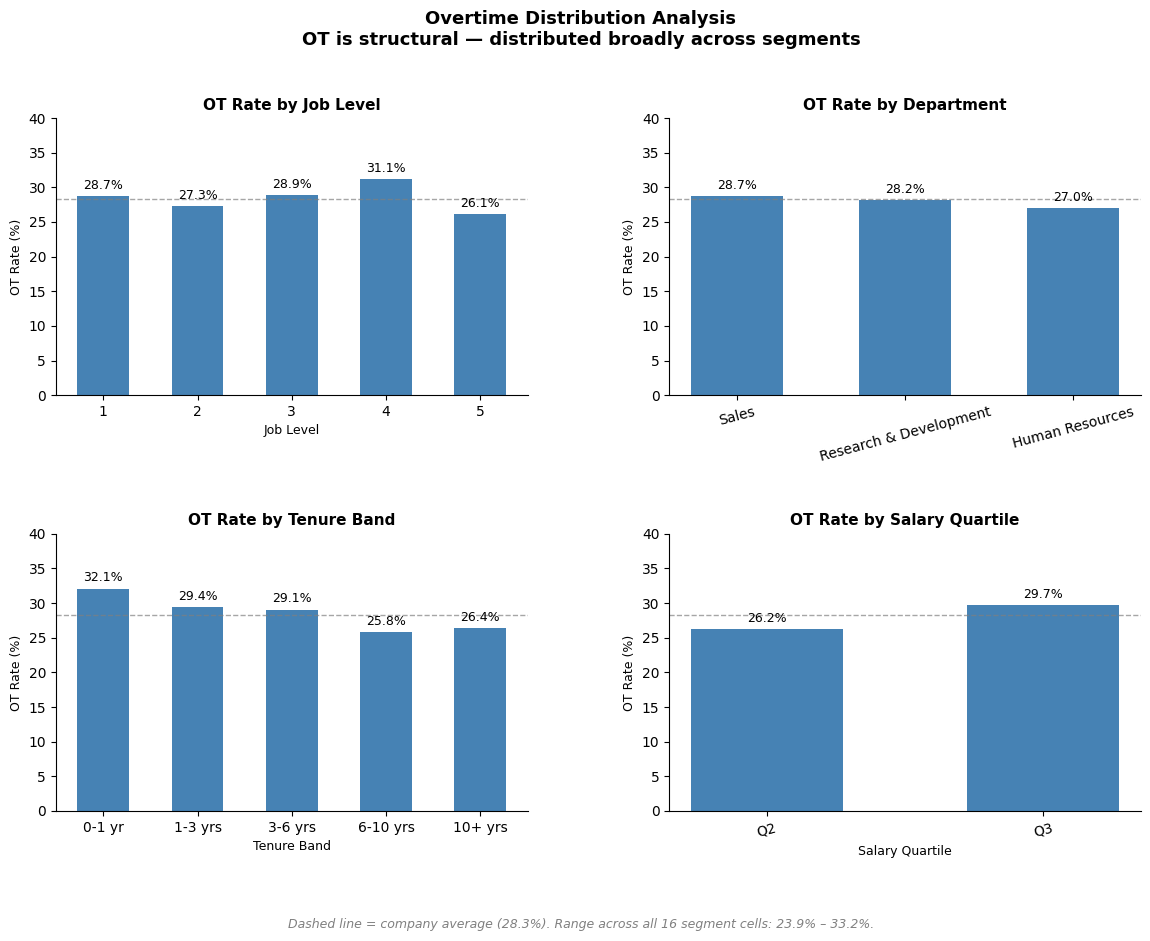

In [23]:
# 4-panel chart showing OT prevalence across segments
# matches Section 3.10-3.13 visually

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.3)
                # gridspec gives finer control over subplot spacing
                # than the basic plt.subplots() approach

company_ot_pct = COMPANY_OT * 100

# ── Panel 1: OT by Job Level ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

ot_by_level = df.groupby('JobLevel')['OT_Flag'].mean() * 100
bars1 = ax1.bar(ot_by_level.index.astype(str), ot_by_level.values,
                color='steelblue', width=0.55)
ax1.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax1.axhline(y=company_ot_pct, color='gray', linestyle='--',
            linewidth=1, alpha=0.7)
ax1.set_title('OT Rate by Job Level', fontsize=11, fontweight='bold')
ax1.set_xlabel('Job Level', fontsize=9)
ax1.set_ylabel('OT Rate (%)', fontsize=9)
ax1.set_ylim(0, 40)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# ── Panel 2: OT by Department ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

ot_by_dept = df.groupby('Department')['OT_Flag'].mean() * 100
ot_by_dept = ot_by_dept.sort_values(ascending=False)
bars2 = ax2.bar(ot_by_dept.index, ot_by_dept.values,
                color='steelblue', width=0.55)
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax2.axhline(y=company_ot_pct, color='gray', linestyle='--',
            linewidth=1, alpha=0.7)
ax2.set_title('OT Rate by Department', fontsize=11, fontweight='bold')
ax2.set_ylabel('OT Rate (%)', fontsize=9)
ax2.set_ylim(0, 40)
ax2.tick_params(axis='x', rotation=15)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# ── Panel 3: OT by Tenure Band ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

ot_by_tenure = df.groupby('Tenure_Band', observed=True)['OT_Flag'].mean() * 100
ot_by_tenure = ot_by_tenure.reindex(tenure_order)
bars3 = ax3.bar(ot_by_tenure.index, ot_by_tenure.values,
                color='steelblue', width=0.55)
ax3.bar_label(bars3, fmt='%.1f%%', padding=3, fontsize=9)
ax3.axhline(y=company_ot_pct, color='gray', linestyle='--',
            linewidth=1, alpha=0.7)
ax3.set_title('OT Rate by Tenure Band', fontsize=11, fontweight='bold')
ax3.set_xlabel('Tenure Band', fontsize=9)
ax3.set_ylabel('OT Rate (%)', fontsize=9)
ax3.set_ylim(0, 40)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)

# ── Panel 4: OT by Salary Quartile ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

ot_by_quartile = df.groupby('Salary_Quartile', observed=True)['OT_Flag'].mean() * 100
ot_by_quartile = ot_by_quartile.reindex(quartile_order)
bars4 = ax4.bar(ot_by_quartile.index, ot_by_quartile.values,
                color='steelblue', width=0.55)
ax4.bar_label(bars4, fmt='%.1f%%', padding=3, fontsize=9)
ax4.axhline(y=company_ot_pct, color='gray', linestyle='--',
            linewidth=1, alpha=0.7)
ax4.set_title('OT Rate by Salary Quartile', fontsize=11, fontweight='bold')
ax4.set_xlabel('Salary Quartile', fontsize=9)
ax4.set_ylabel('OT Rate (%)', fontsize=9)
ax4.set_ylim(0, 40)
ax4.tick_params(axis='x', rotation=15)
for spine in ['top', 'right']:
    ax4.spines[spine].set_visible(False)

# ── Title and footnote ────────────────────────────────────────────────────
fig.suptitle('Overtime Distribution Analysis\n'
             'OT is structural — distributed broadly across segments',
             fontsize=13, fontweight='bold', y=1.00)
fig.text(0.5, -0.02,
         f'Dashed line = company average ({company_ot_pct:.1f}%). '
         'Range across all 16 segment cells: 23.9% – 33.2%.',
         ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

# Reading the chart:
# Every bar clusters tightly around the dashed company-average line.
# If OT were concentrated in a specific subgroup, you'd see one or
# two bars towering above the rest. Instead the chart looks flat —
# which is the visual signature of a structural, company-wide condition.

\#\# Summary of Findings

This descriptive segmentation surfaced five consistent patterns:

1\. \*\*Sales has the highest departmental attrition\*\* \(20\.6%\), driven
   primarily by Sales Representatives at 39\.8% — 2\.5x the company baseline
2\. \*\*Attrition is concentrated at the entry level\*\* — the L1 → L2
   transition produces a 63% relative drop in attrition, the largest
   inflection point in any segmentation
3\. \*\*First\-year employees are the highest\-risk tenure cohort\*\* at 34\.9%,
   compounded to 44\.1% for first\-year \*and\* entry\-level employees
4\. \*\*Lower salary quartiles attrite at nearly 3x the rate of higher
   quartiles\*\* — but this overlaps heavily with career stage
5\. \*\*Overtime workers leave at nearly 3x the rate of non\-OT workers\*\*
   \(30\.5% vs 10\.4%\) — and OT is distributed broadly rather than
   concentrated in any subgroup

Each segment shows attrition risk one variable at a time\. To identify
which factors are \*truly\* driving attrition once others are controlled
for — and to separate signal from confound — we move to \*\*Notebook 3:
Driver Analysis\*\*\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=01782b8c-21ad-4a9f-9322-6be507743988' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>